In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('IRIS.csv')
df.head()

 

In [ ]:
X = df.drop('species',axis=1)

In [ ]:
y = df['species']

In [4]:
from sklearn.model_selection import train_test_split
Itrain,Itest,Dtrain,Dtest = train_test_split(X,y,test_size=0.20,random_state=0)
print(Itrain.shape,Dtrain.shape)
print(Itest.shape,Dtest.shape)

(120, 4) (120,)
(30, 4) (30,)


In [5]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier(n_neighbors=5,p=2)
KNN.fit(Itrain,Dtrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
from sklearn.metrics import confusion_matrix
Dpred = KNN.predict(Itest)
cm = confusion_matrix(Dtest,Dpred)
cm

array([[11,  0,  0],
       [ 0, 12,  1],
       [ 0,  0,  6]])

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X)
X_pca

In [9]:
print("exp variance = ",pca.explained_variance_)

exp variance =  [4.22484077 0.24224357 0.07852391 0.02368303]


In [11]:
print('exp variance ratio=',pca.explained_variance_ratio_)

exp variance ratio= [0.92461621 0.05301557 0.01718514 0.00518309]


In [12]:
np.cumsum(pca.explained_variance_ratio_)

array([0.92461621, 0.97763178, 0.99481691, 1.        ])

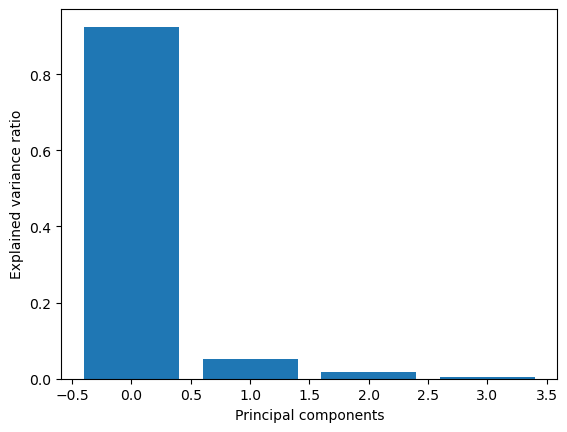

In [13]:
plt.bar(range(4),pca.explained_variance_ratio_,label='individual explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.show()

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# X_pca

In [15]:
from sklearn.model_selection import train_test_split
Itrain,Itest,Dtrain,Dtest = train_test_split(X_pca,y,test_size=0.20,random_state=0)
print(Itrain.shape,Dtrain.shape)
print(Itest.shape,Dtest.shape)

(120, 2) (120,)
(30, 2) (30,)


In [16]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier(n_neighbors=5,p=2)
KNN.fit(Itrain,Dtrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
from sklearn.metrics import confusion_matrix
Dpred = KNN.predict(Itest)
cm = confusion_matrix(Dtest,Dpred)
cm

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]])